# Study 04: RAG Chunking 전략 학습

**목표**: 문서 청킹(Chunking) 개념을 이해하고 최적 파라미터를 찾는 방법을 배웁니다.

**소요 시간**: 약 25분

**비용**: 무료 (로컬 Ollama 사용)

---

## 학습 목표 체크리스트

이 노트북을 완료하면 다음을 할 수 있습니다:

- [ ] 청킹이 무엇인지 설명할 수 있다
- [ ] chunk_size, chunk_overlap 파라미터의 역할을 이해한다
- [ ] RecursiveCharacterTextSplitter를 사용해 문서를 청킹할 수 있다
- [ ] 청킹 파라미터가 검색 품질에 미치는 영향을 이해한다
- [ ] 면접에서 청킹 전략을 설명할 수 있다

## 1. 청킹(Chunking)이란?

### 한 줄 요약
**청킹 = 긴 문서를 검색 가능한 작은 조각으로 나누는 과정**

### 비유로 이해하기

| 일상 생활 | RAG 시스템 |
|----------|------------|
| 두꺼운 책 한 권 | 원본 PDF 문서 |
| 책을 챕터/페이지로 나눔 | **청킹** |
| 목차에서 원하는 페이지 찾기 | 벡터 검색 |

### 시각화

```
원본 문서 (48페이지, 50,000자)
┌─────────────────────────────────────┐
│ 제1장 근무 규정... 제2장 휴가...    │
│ 제3장 급여... 제4장 복리후생...     │
└─────────────────────────────────────┘
                  ↓ 청킹 (chunk_size=1000)
┌──────┐ ┌──────┐ ┌──────┐ ┌──────┐
│청크1 │ │청크2 │ │청크3 │ │...   │
│1000자│ │1000자│ │1000자│ │91개  │
└──────┘ └──────┘ └──────┘ └──────┘
```

## 2. 왜 청킹이 중요한가?

### 문제 상황

```
"연차 휴가 일수가 몇 일이에요?"
```

만약 청킹을 안 하면?
- 48페이지 전체를 LLM에 전달? → 토큰 제한 초과 ❌
- 비용 폭발 💸

적절한 청킹을 하면?
- 연차 관련 청크 1-2개만 검색 ✅
- 정확하고 빠른 응답 🚀

### 현업 표준

| 항목 | 권장 값 | 설명 |
|------|---------|------|
| **Chunk Size** | 500-1500자 | 한글 기준 200-500 단어 |
| **Chunk Overlap** | 10-20% | 문맥 유지를 위한 겹침 |
| **Splitter** | RecursiveCharacterTextSplitter | 단락/문장 경계 우선 분할 |

### 이 프로젝트 설정

| 파라미터 | 값 | 근거 |
|----------|-----|------|
| chunk_size | 1000 | RAGAS 평가 최적 |
| chunk_overlap | 200 | 20% 오버랩 |
| top_k | 5 | 평균 점수 0.851 |

## 3. 핵심 파라미터 이해

### chunk_size (청크 크기)

```
chunk_size=500                    chunk_size=1000
┌─────┐ ┌─────┐ ┌─────┐          ┌───────────┐ ┌───────────┐
│ 500 │ │ 500 │ │ 500 │          │   1000    │ │   1000    │
└─────┘ └─────┘ └─────┘          └───────────┘ └───────────┘
  작은 청크 = 많은 조각             큰 청크 = 적은 조각
  + 정밀한 검색                     + 문맥 보존
  - 문맥 손실 가능                  - 노이즈 포함 가능
```

### chunk_overlap (청크 겹침)

```
overlap=0 (겹침 없음)             overlap=200 (겹침 있음)
┌─────┐┌─────┐┌─────┐            ┌─────┐
│  A  ││  B  ││  C  │            │  A  │
└─────┘└─────┘└─────┘            └─┬───┘
  경계에서 문맥 단절!               ┌─┴───┐
                                  │  B  │ ← A와 200자 겹침
                                  └─┬───┘
                                    ┌─┴───┐
                                    │  C  │
                                    └─────┘
                                  문맥 연결 유지!
```

### 선택 가이드

| 상황 | chunk_size | overlap |
|------|------------|--------|
| 짧은 FAQ | 300-500 | 50 |
| 일반 문서 | 800-1200 | 150-200 |
| 긴 보고서 | 1500-2000 | 300 |

---
## 4. 환경 설정

In [1]:
# 필요한 패키지 설치 (처음 한 번만)
!pip install -q pdfplumber langchain langchain-community faiss-cpu matplotlib

In [2]:
# 임포트 및 경로 설정
import os
import sys
from pathlib import Path

# 프로젝트 루트 설정
project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

# Windows 환경 호환성
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 필수 라이브러리
import pdfplumber
from langchain.schema import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

# 프로젝트 모듈
from core.llm.factory import create_embeddings

print(f"프로젝트 루트: {project_root}")
print("임포트 완료!")

프로젝트 루트: C:\workspace\enterprise-hr-agent
임포트 완료!


In [3]:
# PDF 문서 로드 (pdfplumber 사용)
pdf_path = project_root / "data/company_docs/02_회사규정.pdf"

documents = []
with pdfplumber.open(str(pdf_path)) as pdf:
    for i, page in enumerate(pdf.pages):
        text = page.extract_text()
        if text:
            documents.append(Document(
                page_content=text,
                metadata={"source": pdf_path.name, "page": i + 1}
            ))

print(f"문서 로드 완료!")
print(f"  파일: {pdf_path.name}")
print(f"  페이지 수: {len(documents)}")
print(f"  전체 글자 수: {sum(len(d.page_content) for d in documents):,}")

문서 로드 완료!
  파일: 02_회사규정.pdf
  페이지 수: 48
  전체 글자 수: 55,637


---
## 5. RecursiveCharacterTextSplitter 이해

### 왜 Recursive인가?

**일반 TextSplitter**: 무조건 N자마다 자름 → 문장 중간에서 끊김 😞

**RecursiveCharacterTextSplitter**: 계층적 분할 시도 → 자연스러운 경계 👍

```python
separators=["\n\n", "\n", " ", ""]
         ↓
1. 먼저 빈 줄(\n\n)로 나누기 시도 (단락 단위)
2. 안 되면 줄바꿈(\n)으로 시도
3. 안 되면 공백( )으로 시도
4. 최후 수단: 글자 단위로 자름
```

### 결과
- 문단/문장 경계를 최대한 유지
- 읽기 자연스러운 청크 생성

In [4]:
# 기본 청킹 실습: 현재 프로젝트 설정 (chunk_size=1000, overlap=200)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,      # 청크 최대 크기 (글자 수)
    chunk_overlap=200,    # 청크 간 겹침 (글자 수)
    separators=["\n\n", "\n", " ", ""]  # 분할 우선순위
)

# 청킹 실행
chunks = text_splitter.split_documents(documents)

print(f"청킹 완료!")
print(f"  원본 페이지: {len(documents)}")
print(f"  생성된 청크: {len(chunks)}")
print(f"  평균 청크 크기: {sum(len(c.page_content) for c in chunks) // len(chunks)} 글자")

청킹 완료!
  원본 페이지: 48
  생성된 청크: 91
  평균 청크 크기: 694 글자


In [5]:
# 청크 내용 확인

print("=" * 60)
print("청크 샘플 (처음 3개)")
print("=" * 60)

for i, chunk in enumerate(chunks[:3]):
    print(f"\n[청크 {i+1}] (길이: {len(chunk.page_content)}자)")
    print(f"출처: {chunk.metadata}")
    print("-" * 40)
    # 처음 200자만 출력
    preview = chunk.page_content[:200].replace("\n", " ")
    print(f"{preview}...")

청크 샘플 (처음 3개)

[청크 1] (길이: 979자)
출처: {'source': '02_회사규정.pdf', 'page': 1}
----------------------------------------
## 서문: 용어 정의 본 규정에서 사용하는 주요 용어의 정의는 다음과 같다. ### 고용 및 인사 관련 용어 | 용어 | 정의 | |------|------| | **정규직** | 기간의 정함이 없는 근로계약을 체결한 직원으로, 수습 기간을 완료하고 정식 임용된 자를 말한다. | | **계약직** | 1 년 이하의 기간을 정하여 근로계약을 체결한 직원을 ...

[청크 2] (길이: 1000자)
출처: {'source': '02_회사규정.pdf', 'page': 2}
----------------------------------------
| **휴일근로** | 법정휴일 또는 회사 지정 휴일에 근무하는 것을 말하며, 대체휴무 또는 휴일근로수당으로 보상한다. | | **대체휴무** | 휴일근로에 대해 금전 보상 대신 다른 날 휴무를 부여하는 것을 말한다. | | **재택근무** | 회사 사무실이 아닌 자택 등에서 정보통신기기를 활용하여 업무를 수행하는 근무 형태를 말한다. | | **워케이션*...

[청크 3] (길이: 977자)
출처: {'source': '02_회사규정.pdf', 'page': 3}
----------------------------------------
| **정성평가** | 협업 태도, 조직 기여도 등 수치화하기 어려운 역량을 평가하는 방식을 말한다. | | **다면평가** | 상급자뿐 아니라 동료, 하급자 등 다양한 평가자가 참여하는 평가 방식을 말한다. | | **KPI(핵심성과지표)** | Key Performance Indicator 의 약자로, 개인 또는 조직의 성과를 측정하는 핵심 지표를 말한...


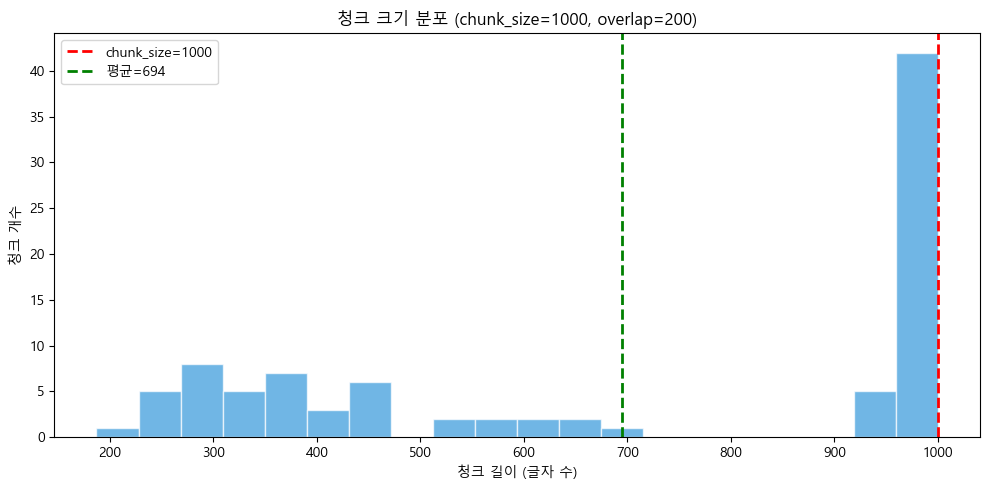


통계:
  최소: 187 글자
  최대: 1000 글자
  평균: 694 글자


In [6]:
# 청크 크기 분포 시각화
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 청크 길이 계산
chunk_lengths = [len(c.page_content) for c in chunks]

# 히스토그램
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(chunk_lengths, bins=20, color='#3498db', edgecolor='white', alpha=0.7)
ax.axvline(x=1000, color='red', linestyle='--', linewidth=2, label=f'chunk_size=1000')
ax.axvline(x=sum(chunk_lengths)/len(chunk_lengths), color='green', linestyle='--', 
           linewidth=2, label=f'평균={sum(chunk_lengths)//len(chunk_lengths)}')

ax.set_xlabel('청크 길이 (글자 수)')
ax.set_ylabel('청크 개수')
ax.set_title('청크 크기 분포 (chunk_size=1000, overlap=200)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n통계:")
print(f"  최소: {min(chunk_lengths)} 글자")
print(f"  최대: {max(chunk_lengths)} 글자")
print(f"  평균: {sum(chunk_lengths)//len(chunk_lengths)} 글자")

---
## 6. 파라미터 튜닝 실험

### 비교할 설정

| 설정 | chunk_size | overlap | 예상 특성 |
|------|------------|---------|----------|
| 소형 | 500 | 50 | 많은 청크, 정밀 검색 |
| **권장** | 1000 | 200 | 균형잡힌 설정 |
| 대형 | 1500 | 300 | 적은 청크, 넓은 문맥 |

In [7]:
# 여러 설정 비교 실험

configs = [
    {"name": "소형 (500/50)", "chunk_size": 500, "overlap": 50},
    {"name": "권장 (1000/200)", "chunk_size": 1000, "overlap": 200},
    {"name": "대형 (1500/300)", "chunk_size": 1500, "overlap": 300},
]

print("설정별 청크 생성 결과")
print("=" * 50)

results = []
for config in configs:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=config["chunk_size"],
        chunk_overlap=config["overlap"],
        separators=["\n\n", "\n", " ", ""]
    )
    chunks = splitter.split_documents(documents)
    
    avg_len = sum(len(c.page_content) for c in chunks) // len(chunks)
    results.append({
        "name": config["name"],
        "chunk_count": len(chunks),
        "avg_length": avg_len
    })
    
    print(f"{config['name']:15} → {len(chunks):3} 청크, 평균 {avg_len} 글자")

print()
print("💡 청크가 많을수록 검색 정밀도 ↑, 적을수록 문맥 보존 ↑")

설정별 청크 생성 결과
소형 (500/50)     → 147 청크, 평균 397 글자
권장 (1000/200)   →  91 청크, 평균 694 글자
대형 (1500/300)   →  48 청크, 평균 1159 글자

💡 청크가 많을수록 검색 정밀도 ↑, 적을수록 문맥 보존 ↑


In [8]:
# 검색 품질 비교 테스트

# 임베딩 모델 초기화 (로컬 Ollama)
embeddings = create_embeddings(
    provider="ollama",
    model="snowflake-arctic-embed2",
    base_url="http://localhost:11434"
)

print("임베딩 모델 초기화 완료")

# 각 설정으로 인덱스 생성 및 검색 테스트
test_query = "연차휴가 일수는 몇 일인가요?"

print(f"\n테스트 쿼리: {test_query}")
print("=" * 60)

for config in configs:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=config["chunk_size"],
        chunk_overlap=config["overlap"],
        separators=["\n\n", "\n", " ", ""]
    )
    chunks = splitter.split_documents(documents)
    
    # 인덱스 생성
    vectorstore = FAISS.from_documents(chunks, embeddings)
    
    # 검색
    results = vectorstore.similarity_search(test_query, k=1)
    
    print(f"\n[{config['name']}]")
    print(f"검색된 청크 ({len(results[0].page_content)}자):")
    preview = results[0].page_content[:300].replace("\n", " ")
    print(f"{preview}...")

임베딩 모델 초기화 완료

테스트 쿼리: 연차휴가 일수는 몇 일인가요?

[소형 (500/50)]
검색된 청크 (499자):
A. 네, 포함됩니다. 근로기준법상 1 주 최대 근로시간은 기본 40 시간 + 연장/휴일 12 시간 = 52 시간입니다. 단, 특별연장근로 인가 사유에 해당하면 노사 합의 하에 추가 연장이 가능합니다. ### 휴가 **Q8. 연차를 시간 단위로 사용할 수 있나요?** A. 네, 가능합니다. 1 일 연차는 7.5 시간으로 환산되며, 최소 1 시간 단위로 사용할 수 있습니다. 단, 시간 단위 연차 사용은 연간 총 연차 일수의 50%까지만 가능합니다. **Q9. 병가 사용 시 진단서가 반드시 필요한가요?** A. 3 일 이하 병가는 진단...

[권장 (1000/200)]
검색된 청크 (975자):
• 사례 5: E 직원이 연락 없이 2 일 연속 결근한 경우 → 서면 경위서 제출 요구, 미제출 시 추가 징계 검토 **제12 조 연차·병가·특별휴가의 수칙** 연차는 입사 첫해 월 1 일씩 최대 11 일을 부여한다. 1 년 이상 근속 시 매년 15 일을 부여하고, 근속 3 년 차부터 2 년마다 1 일씩 추가하여 최대 25 일까지 부여한다. 병가는 연 7 일을 지급하며, 3 일 이상 사용 시 진단서를 요구할 수 있다. 회사는 필요 시 특정 인력에게 특별휴가를 부여할 수 있으며, 부여 기준은 회사 방침에 따른다. **제12 조의2 휴...

[대형 (1500/300)]
검색된 청크 (1274자):
• 사례 5: E 직원이 연락 없이 2 일 연속 결근한 경우 → 서면 경위서 제출 요구, 미제출 시 추가 징계 검토 **제12 조 연차·병가·특별휴가의 수칙** 연차는 입사 첫해 월 1 일씩 최대 11 일을 부여한다. 1 년 이상 근속 시 매년 15 일을 부여하고, 근속 3 년 차부터 2 년마다 1 일씩 추가하여 최대 25 일까지 부여한다. 병가는 연 7 일을 지급하며, 3 일 이상 사용 시 진단서를 요구할 수 있다. 회사는 필요 시 특정 인력에게 특별휴가

---
## 7. RAGAS 평가 결과 분석

### 이 프로젝트의 실험 결과

RAGAS 프레임워크로 4가지 설정을 평가한 결과:

| 설정 | Context Precision | Context Recall | 평균 |
|------|-------------------|----------------|------|
| **권장 (1000/200), k=5** | 0.702 | 1.000 | **0.851** |
| 권장 (1000/200), k=3 | 0.692 | 0.900 | 0.796 |
| 현재 (500/50), k=5 | 0.553 | 1.000 | 0.776 |
| 현재 (500/50), k=3 | 0.558 | 0.800 | 0.679 |

### 결론

- **chunk_size=1000, overlap=200, top_k=5**가 최적
- 큰 청크 + 높은 오버랩 = 더 나은 성능
- Context Recall 1.0 = 필요한 정보를 모두 검색

### 왜 이런 결과가?

1. **청크가 너무 작으면** (500자)
   - 문맥이 잘림 → 관련 정보지만 낮은 유사도
   - Precision 낮아짐

2. **청크가 적당하면** (1000자)
   - 충분한 문맥 포함 → 정확한 검색
   - Precision과 Recall 모두 높음

---
## 8. 고급: add_start_index 옵션

### 용도
각 청크가 원본 문서의 어디서 시작하는지 기록

### 언제 유용한가?
- 원문 위치 표시 ("3페이지 1200자 부분")
- 청크 병합/재구성
- 디버깅

In [9]:
# add_start_index 실습

text_splitter_with_index = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    add_start_index=True,  # 시작 위치 기록!
    separators=["\n\n", "\n", " ", ""]
)

chunks_with_index = text_splitter_with_index.split_documents(documents)

print("add_start_index=True 결과")
print("=" * 50)

for i, chunk in enumerate(chunks_with_index[:5]):
    start_idx = chunk.metadata.get("start_index", "N/A")
    page = chunk.metadata.get("page", "N/A")
    print(f"청크 {i+1}: 페이지 {page}, 시작 위치 {start_idx}, 길이 {len(chunk.page_content)}자")

print()
print("💡 start_index로 원문 위치를 추적할 수 있습니다!")

add_start_index=True 결과
청크 1: 페이지 1, 시작 위치 0, 길이 979자
청크 2: 페이지 2, 시작 위치 0, 길이 1000자
청크 3: 페이지 3, 시작 위치 0, 길이 977자
청크 4: 페이지 3, 시작 위치 806, 길이 382자
청크 5: 페이지 4, 시작 위치 0, 길이 955자

💡 start_index로 원문 위치를 추적할 수 있습니다!


---
## 9. 핵심 정리

### 배운 내용 요약

| 개념 | 설명 |
|------|------|
| 청킹 | 긴 문서를 작은 조각으로 분할 |
| chunk_size | 청크 최대 크기 (글자 수) |
| chunk_overlap | 청크 간 겹침 (문맥 유지) |
| RecursiveCharacterTextSplitter | 단락/문장 경계 우선 분할 |

### 현업 권장 설정

```python
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,      # 현업 표준: 800-1200
    chunk_overlap=200,    # 현업 표준: 10-20%
    separators=["\n\n", "\n", " ", ""]
)
```

### 면접 답변 예시

> **Q: RAG 시스템에서 청킹 전략을 어떻게 결정하셨나요?**
>
> A: "RAGAS 프레임워크로 Grid Search 방식으로 최적화했습니다.  
> chunk_size(500/1000/1500), overlap(50/200/300) 조합을 테스트하여  
> Context Precision과 Recall 기준으로 **chunk_size=1000, overlap=200**이  
> 평균 점수 0.851로 최적임을 확인했습니다.  
> RecursiveCharacterTextSplitter를 사용해 단락/문장 경계를 유지했습니다."

---
## 참고 자료

### 공식 문서
- [LangChain Text Splitters](https://python.langchain.com/docs/how_to/recursive_text_splitter/)
- [RAGAS Documentation](https://docs.ragas.io/)

### 관련 파일
- `scripts/build_index.py` - 인덱스 빌드 스크립트 (청킹 로직)
- `notebooks/rag_ragas_evaluation.ipynb` - RAGAS 평가 노트북

### 다음 학습
- **study_05_embeddings.ipynb**: 임베딩 모델 비교

---

**수고하셨습니다!** 🎉

청킹은 RAG 성능의 핵심입니다. 파라미터를 조정하며 실험해보세요!